In [31]:
pip install tensorflow-gpu

  Using cached tensorflow-gpu-2.12.0.tar.gz (2.6 kB)
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [2]:
# importing important libraries

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [75]:
df = pd.read_csv('/content/test.csv')

In [65]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,52685,36,Male,13,Healthcare,8029,Excellent,High,Average,1,...,1,Mid,Large,22,No,No,No,Poor,Medium,Stayed
1,30585,35,Male,7,Education,4563,Good,High,Average,1,...,4,Entry,Medium,27,No,No,No,Good,High,Left
2,54656,50,Male,7,Education,5583,Fair,High,Average,3,...,2,Senior,Medium,76,No,No,Yes,Good,Low,Stayed
3,33442,58,Male,44,Media,5525,Fair,Very High,High,0,...,4,Entry,Medium,96,No,No,No,Poor,Low,Left
4,15667,39,Male,24,Education,4604,Good,High,Average,0,...,6,Mid,Large,45,Yes,No,No,Good,High,Stayed


In [66]:
df.dtypes

,0
Employee ID,int64
Age,int64
Gender,object
Years at Company,int64
Job Role,object
Monthly Income,int64
Work-Life Balance,object
Job Satisfaction,object
Performance Rating,object
Number of Promotions,int64


In [76]:
df.shape

(14900, 24)

In [77]:
# Drop duplicates and irrelevant column
df = df.drop_duplicates()
df = df.drop(['Employee ID'], axis=1)
print("After removing duplicates:", df.shape)

After removing duplicates: (14900, 23)


In [78]:
# Target variable
y = df['Attrition'].map({'Stayed': 0, 'Left': 1})
X = df.drop('Attrition', axis=1)

In [79]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols)

# Convert categorical columns using one-hot encoding
X= pd.get_dummies(X, columns=cat_cols, drop_first=True)

Categorical columns: ['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']


In [81]:
X.head()

,Age,Years at Company,Monthly Income,Number of Promotions,Distance from Home,Number of Dependents,Company Tenure,Gender_Male,Job Role_Finance,Job Role_Healthcare,...,Company Size_Small,Remote Work_Yes,Leadership Opportunities_Yes,Innovation Opportunities_Yes,Company Reputation_Fair,Company Reputation_Good,Company Reputation_Poor,Employee Recognition_Low,Employee Recognition_Medium,Employee Recognition_Very High
0,36,13,8029,1,83,1,22,True,False,True,...,False,False,False,False,False,False,True,False,True,False
1,35,7,4563,1,55,4,27,True,False,False,...,False,False,False,False,False,True,False,False,False,False
2,50,7,5583,3,14,2,76,True,False,False,...,False,False,False,True,False,True,False,True,False,False
3,58,44,5525,0,43,4,96,True,False,False,...,False,False,False,False,False,False,True,True,False,False
4,39,24,4604,0,47,6,45,True,False,False,...,False,True,False,False,False,True,False,False,False,False


In [82]:
X.dtypes

,0
Age,int64
Years at Company,int64
Monthly Income,int64
Number of Promotions,int64
Distance from Home,int64
Number of Dependents,int64
Company Tenure,int64
Gender_Male,bool
Job Role_Finance,bool
Job Role_Healthcare,bool


In [83]:
X.isna().sum()


,0
Age,0
Years at Company,0
Monthly Income,0
Number of Promotions,0
Distance from Home,0
Number of Dependents,0
Company Tenure,0
Gender_Male,0
Job Role_Finance,0
Job Role_Healthcare,0


In [84]:
#Splitting dataset in Train Test Set

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size = 0.2,  random_state=42, stratify=y)


In [85]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [86]:
y.value_counts()


,count
Attrition,
0,7868
1,7032


In [87]:
X_train.shape

(11920, 41)

In [88]:
X_test.shape

(2980, 41)

In [97]:
#Initializing ANN

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Model
classifier = Sequential([
    tf.keras.Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])


# Compile
classifier.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', 'Precision', 'Recall', 'AUC']
)

In [98]:

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)

# Train the model
history = classifier.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=150,                # Slightly more epochs
    batch_size=32,             # Slightly larger batch
    #class_weight=class_weights, # For handling imbalance
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - AUC: 0.6299 - Precision: 0.5706 - Recall: 0.5754 - accuracy: 0.5928 - loss: 0.7553 - val_AUC: 0.8129 - val_Precision: 0.7370 - val_Recall: 0.6854 - val_accuracy: 0.7324 - val_loss: 0.5247 - learning_rate: 0.0010
Epoch 2/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7862 - Precision: 0.6991 - Recall: 0.6782 - accuracy: 0.7116 - loss: 0.5603 - val_AUC: 0.8297 - val_Precision: 0.7368 - val_Recall: 0.7213 - val_accuracy: 0.7433 - val_loss: 0.5017 - learning_rate: 0.0010
Epoch 3/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.7975 - Precision: 0.7061 - Recall: 0.6922 - accuracy: 0.7196 - loss: 0.5444 - val_AUC: 0.8362 - val_Precision: 0.7416 - val_Recall: 0.7169 - val_accuracy: 0.7450 - val_loss: 0.4934 - learning_rate: 0.0010
Epoch 4/150
298/298 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - AUC: 0.8190 - Precision: 0.7260 - Recall: 0.7180 - accuracy: 0.7400 - loss: 0.5183 - val_AUC: 0.8392 - val_Precision: 0.7425 - val_Recall: 0.73

In [101]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Predict probabilities and classes
y_pred_prob = classifier.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Compute metrics
acc = accuracy_score(Y_test, y_pred)
prec = precision_score(Y_test, y_pred)
rec = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
auc = roc_auc_score(Y_test, y_pred_prob)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(Y_test, y_pred))


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.7450
Precision: 0.7304
Recall: 0.7283
F1-Score: 0.7293
AUC: 0.8348

Confusion Matrix:
[[1196  378]
 [ 382 1024]]


In [105]:
# Take first 5 rows from your test set
X_sample = X_test[:5]
y_sample = Y_test[:5]

# Predict probabilities and classes
y_sample_prob = classifier.predict(X_sample)
y_sample_class = (y_sample_prob > 0.5).astype(int)

# Display results
for i in range(len(X_sample)):
    print(f"Sample {i+1}:")
    print(f"  True label: {y_sample.iloc[i]}")
    print(f"  Predicted probability of leaving: {y_sample_prob[i][0]:.4f}")
    print(f"  Predicted class (0=Stayed, 1=Left): {y_sample_class[i][0]}")
    print()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Sample 1:
  True label: 1
  Predicted probability of leaving: 0.5775
  Predicted class (0=Stayed, 1=Left): 1

Sample 2:
  True label: 1
  Predicted probability of leaving: 0.7830
  Predicted class (0=Stayed, 1=Left): 1

Sample 3:
  True label: 0
  Predicted probability of leaving: 0.6336
  Predicted class (0=Stayed, 1=Left): 1

Sample 4:
  True label: 0
  Predicted probability of leaving: 0.3954
  Predicted class (0=Stayed, 1=Left): 0

Sample 5:
  True label: 1
  Predicted probability of leaving: 0.6732
  Predicted class (0=Stayed, 1=Left): 1



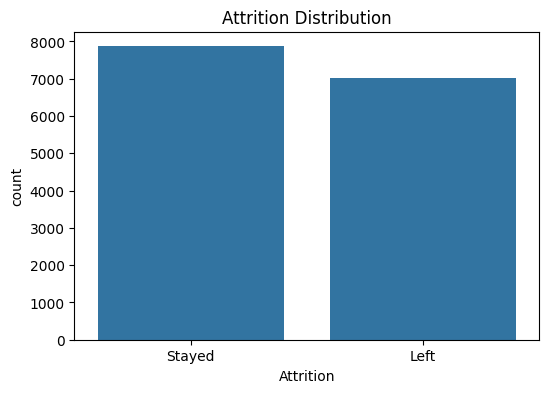

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix

# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y.map({0:'Stayed', 1:'Left'}))
plt.title("Attrition Distribution")
plt.show()

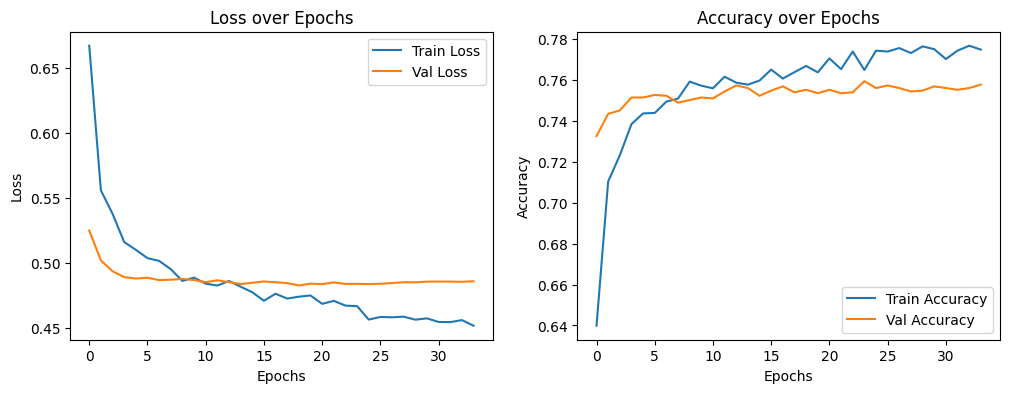

In [108]:
# Training History Visualization
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


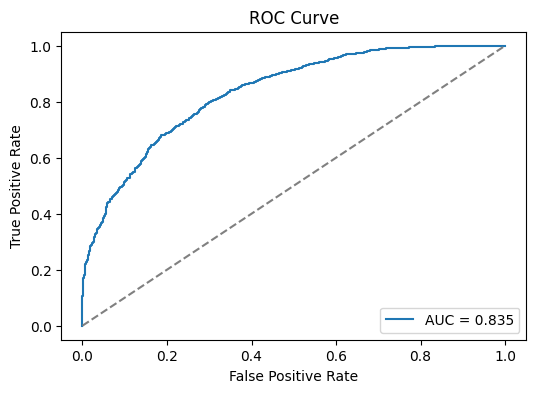

In [109]:
# ROC Curve

y_prob = classifier.predict(X_test)
fpr, tpr, thresholds = roc_curve(Y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc='lower right')
plt.show()
